Connected to base (Python 3.9.13)

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import pandas as pd
adata = sc.read_h5ad("/home/yzhao4/new_repo_branchpoint/branch-point-prediction/Simulation/dyngen/tutorial/tuto.h5ad")

In [2]:
# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)

sc.pp.highly_variable_genes(adata, n_top_genes=135)
sc.tl.pca(adata)
sc.pp.neighbors(adata)

/home/yzhao4/Software/anaconda3/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:220: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby('mean_bin')['dispersions']
2025-02-18 16:10:42.067750: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-02-18 16:10:42.219496: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2025

/home/yzhao4/Software/anaconda3/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/yzhao4/Software/anaconda3/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


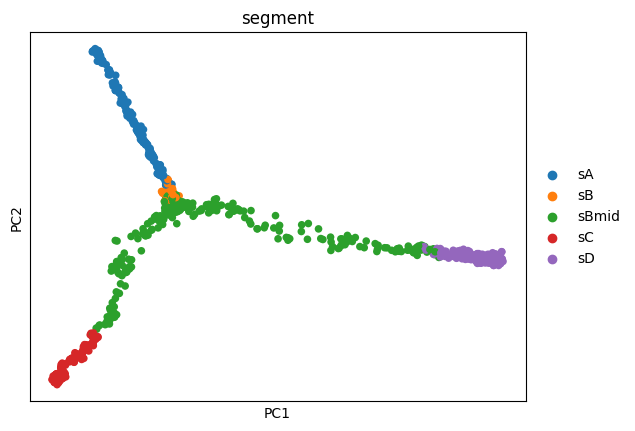

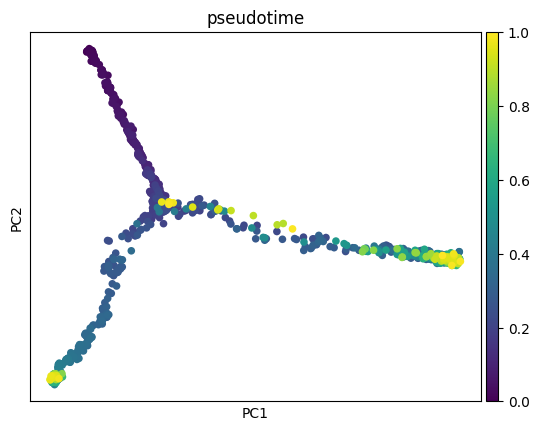

In [3]:
#sc.tl.umap(adata)
segment = pd.DataFrame(adata.uns["traj_progressions"]['from'])
segment.index = adata.obs_names
adata.obs['segment'] = segment
sc.pl.pca(adata, color = 'segment')

#check pseudotime
adata.obs['sim_time']
adata.obs['pseudotime'] = adata.obs['sim_time'] / max(adata.obs['sim_time'])
sc.pl.pca(adata, color = 'pseudotime')

In [4]:

adata.obs['simulation_i']
set(adata.obs['simulation_i'])

{1, 2, 3, 4, 5, 6, 7, 8, 9, 10}

/home/yzhao4/Software/anaconda3/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/yzhao4/Software/anaconda3/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


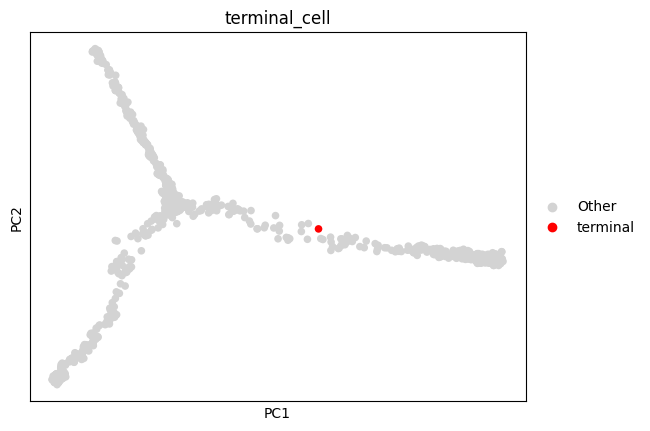

In [5]:

#plot 1000th, 999th cell
adata.obs['terminal_cell'] = np.where(adata.obs['sim_time'] >= 995, 'terminal', 'Other')
sc.pl.pca(adata, color='terminal_cell', palette={'Other': 'lightgray', 'terminal': 'red'})


In [6]:

# for pca embedding, find cell in the corner
adata[(adata.obsm['X_pca'][:,0] <= -19) & (adata.obsm['X_pca'][:,1] <= -23)].obs_names  #cell855
adata[adata.obsm['X_pca'][:,0] > 30.1].obs_names #cell170


Index(['cell170'], dtype='object')

/home/yzhao4/Software/anaconda3/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/yzhao4/Software/anaconda3/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


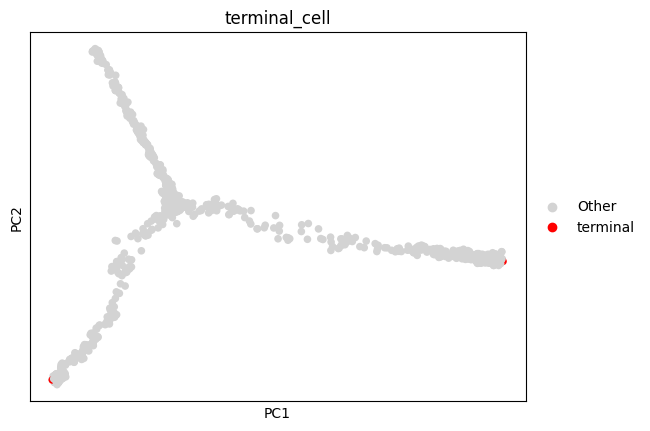

In [7]:

terminal_cell_info = np.where(adata.obs['sim_time'] >= 1000, 'terminal', 'Other')
terminal_cell_info[854] = 'terminal'
terminal_cell_info[169] = 'terminal'
adata.obs['terminal_cell'] = terminal_cell_info
sc.pl.pca(adata, color='terminal_cell', palette={'Other': 'lightgray', 'terminal': 'red'})


In [8]:
max(adata.obsm['X_pca'][:,1])

30.60773

In [9]:
adata[adata.obsm['X_pca'][:,1] > 30.6]

View of AnnData object with n_obs × n_vars = 1 × 135
    obs: 'step_ix', 'simulation_i', 'sim_time', 'segment', 'pseudotime', 'terminal_cell'
    var: 'module_id', 'basal', 'burn', 'independence', 'color', 'is_tf', 'is_hk', 'transcription_rate', 'splicing_rate', 'translation_rate', 'mrna_halflife', 'protein_halflife', 'mrna_decay_rate', 'protein_decay_rate', 'max_premrna', 'max_mrna', 'max_protein', 'mol_premrna', 'mol_mrna', 'mol_protein', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'traj_dimred_segments', 'traj_milestone_network', 'traj_progressions', 'log1p', 'hvg', 'pca', 'neighbors', 'segment_colors', 'terminal_cell_colors'
    obsm: 'dimred', 'X_pca'
    varm: 'PCs'
    layers: 'counts_protein', 'counts_spliced', 'counts_unspliced', 'logcounts'
    obsp: 'distances', 'connectivities'

In [10]:
adata[adata.obsm['X_pca'][:,1] > 30.6].obs_names 

Index(['cell466'], dtype='object')

In [14]:
#run palantir
import palantir

dm_res = palantir.utils.run_diffusion_maps(adata, n_components=5)
ms_data = palantir.utils.determine_multiscale_space(adata)


In [15]:
terminal_states = pd.Series(
    ["sC", "sD"],
    index=["cell855", "cell170"],
)

In [16]:
start_cell = "cell466"
pr_res = palantir.core.run_palantir(
    adata, start_cell, num_waypoints=300, terminal_states=terminal_states
)

Sampling and flocking waypoints...
Time for determining waypoints: 0.0010543306668599447 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 1.240283739566803 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


In [19]:
adata

AnnData object with n_obs × n_vars = 1000 × 135
    obs: 'step_ix', 'simulation_i', 'sim_time', 'segment', 'pseudotime', 'terminal_cell', 'palantir_pseudotime', 'palantir_entropy'
    var: 'module_id', 'basal', 'burn', 'independence', 'color', 'is_tf', 'is_hk', 'transcription_rate', 'splicing_rate', 'translation_rate', 'mrna_halflife', 'protein_halflife', 'mrna_decay_rate', 'protein_decay_rate', 'max_premrna', 'max_mrna', 'max_protein', 'mol_premrna', 'mol_mrna', 'mol_protein', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'traj_dimred_segments', 'traj_milestone_network', 'traj_progressions', 'log1p', 'hvg', 'pca', 'neighbors', 'segment_colors', 'terminal_cell_colors', 'DM_EigenValues', 'palantir_waypoints'
    obsm: 'dimred', 'X_pca', 'DM_EigenVectors', 'DM_EigenVectors_multiscaled', 'palantir_fate_probabilities'
    varm: 'PCs'
    layers: 'counts_protein', 'counts_spliced', 'counts_unspliced', 'logcounts'
    obsp: 'distances', 'connectivities', 'DM_Kernel',

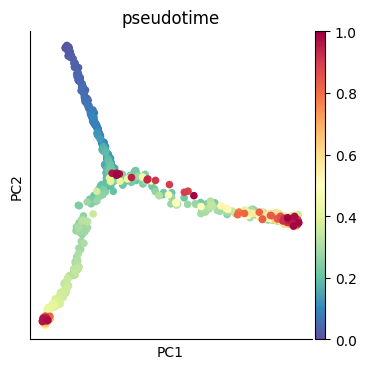

In [20]:
sc.pl.pca(adata, color = 'pseudotime')

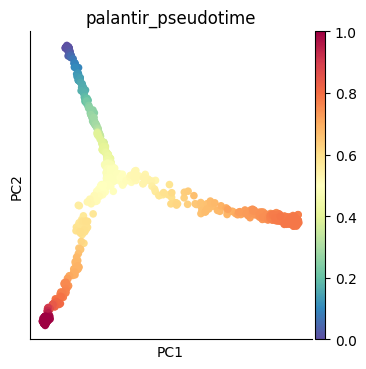

In [22]:
sc.pl.pca(adata, color = 'palantir_pseudotime')

In [23]:
adata.write_h5ad('/home/yzhao4/new_repo_branchpoint/Data/Simulation/Dyngen/tutorial_data/dyngen_after_palantir.h5ad')

In [24]:
sc.set_figure_params(api = 300)
sc.pl.pca(adata, color = 'palantir_pseudotime', save='_pca_plot.png')

TypeError: set_figure_params() got an unexpected keyword argument 'api'

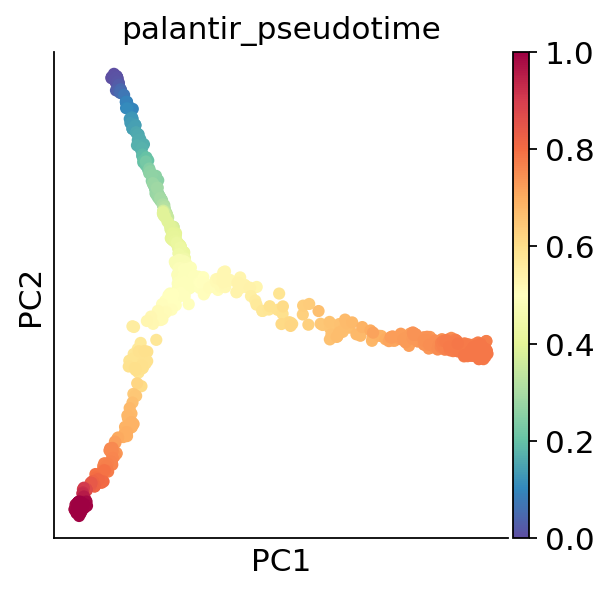

In [25]:
sc.set_figure_params(dpi_save = 300)
sc.pl.pca(adata, color = 'palantir_pseudotime', save='_pca_plot.png')
